# 04 · Putting it together: the 2030 gap (RQ2)

Chapter 4 of *Mapping the Consumption Gap*, part 1. Demand scenarios for 2030 under four counting rules (the proposal's upper bound, the CEC's central case, an ERCOT-calibrated stock-flow case and a PJM-style firm-only case) on top of the IEPR's low/mid/high non-data-center growth; a 10,000-draw Monte Carlo of the 2030 energy and net-peak gap against the probability-weighted supply of chapter 3; and one-at-a-time and Sobol sensitivity.

Outputs are produced by `scripts/run_chapter4.py` from `src/ch4_gap.py` (about a minute); this notebook displays them.

| Step | Sources (manifest ids) |
|---|---|
| 1. Tiers and IEPR growth | `cec_assembly_hearing_2026_01_28`, `cec_dc_methodology_memo_2026`, `cec_tn268722/268727/268725/268726` (CED 2025 forms), `cec_tn268124` (peak components), `cec_tn268824` (data center deliveries) |
| 2. ERCOT stock-flow | `ercot_board_2025_12_system_planning`, `ercot_tac_2026_03_large_load_status`, `ercot_monthly_2025_07 .. 2026_06`, `ercot_house_hearing_2026_04_09`, `ercot_board_2026_05_interconnection_update`, `ercot_ops_overview_2026_06/08` |
| 3. Demand cases | the above plus `pjm_lar_summary_2025_11_24` (PJM rules) |
| 4-5. Monte Carlo and sensitivity | chapter 3 outputs (`ch3_cases_2030`, `ch3_planned_current_weighted`, `ch3_capacity_factors`, `ch3_elcc_values`, `ch3_supply_by_year`, `ch3_cec_imports_by_year`) |


In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
import pandas as pd, numpy as np
from IPython.display import Image, display
from src.paths import PROCESSED, FIGURES
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 90)
def show(name): display(Image(filename=str(FIGURES / f"{name}.png")))
def table(name, **kw): return pd.read_csv(PROCESSED / f"{name}.csv", **kw).convert_dtypes()  # integer-valued columns display as integers

## 1. California tiers and the IEPR's non-data-center growth

The December 2025 tiers are the CEC's published statewide totals minus VEA's requests, which are in Nevada. Non-data-center demand in 2025 and 2030 is the CED 2025 statewide energy to serve load and coincident peak minus the CEC's own data center component (energy from the Planning forecast's data center allocations, peak from the CAISO DATA_CENTER column of the peak workbook). Low = Planning (managed), mid = Baseline (before AAEE/AAFS), high = Local Reliability; the Local Reliability plus known loads case is shown for reference.

In [2]:
table("ch4_ca_tiers")

,tier,mw_california,mw_all_reporting,mw_excluded_nevada,utility_rows_california_mw,source
0,Signed agreement,5086,5086,0,5086,cec_assembly_hearing_2026_01_28 p.7 statewide tier totals; cec_dc_methodology_memo_202...
1,Active application,6987,9587,2600,6987,cec_assembly_hearing_2026_01_28 p.7 statewide tier totals; cec_dc_methodology_memo_202...
2,Inquiry,8604,8604,0,8605,cec_assembly_hearing_2026_01_28 p.7 statewide tier totals; cec_dc_methodology_memo_202...


In [3]:
json.loads((PROCESSED / "ch4_cec_parameters.json").read_text())

{'confidence': {'Inquiry|mid': 0.0,
  'Inquiry|high': 0.1,
  'Application|mid': 0.33,
  'Application|high': 0.5,
  'Agreement|mid': 0.7,
  'Agreement|high': 1.0},
 'utilization': 0.67,
 'ramp_years': 7,
 'group1_start_year': 2026,
 'group23_start_year': 2028,
 'load_factor_range': [0.85, 0.9],
 'basis': 'cec_dc_methodology_memo_2026 Table 2 (p. 8-9): 67% utilization; confidence 70/33/0 (Planning) and 100/50/10 (Local Reliability); linear ramp over 7 years; Group 2 start dates without a signed agreement moved to 2028; hourly load factors 85-90% of annual maximum (p. 11)'}

In [4]:
g = table("ch4_iepr_growth_cases"); g.round(0)

,case,scenario,year,energy_statewide_GWh,dc_energy_GWh,energy_non_dc_GWh,peak_statewide_MW,dc_peak_caiso_MW,dc_peak_vea_MW,peak_non_dc_MW,caiso_peak_MW,caiso_energy_GWh
0,low,Planning,2025,263196.0,729.0,262467.0,57560.0,96,0,57464.0,46479,212700.0
1,low,Planning,2030,298167.0,12078.0,286089.0,62832.0,1743,160,61089.0,50498,244109.0
2,mid,Baseline,2025,263989.0,729.0,263260.0,57560.0,96,0,57464.0,46479,213493.0
3,mid,Baseline,2030,315818.0,12078.0,303740.0,64195.0,1743,160,62452.0,51485,260714.0
4,high,Local Reliability,2025,263415.0,927.0,262489.0,57562.0,122,0,57440.0,46481,212918.0
5,high,Local Reliability,2030,338104.0,30330.0,307773.0,67610.0,4377,242,63233.0,54839,281002.0
6,high plus known loads,Local Reliability plus known,2025,263415.0,927.0,262489.0,57562.0,122,0,57440.0,46481,212918.0
7,high plus known loads,Local Reliability plus known,2030,357330.0,30365.0,326965.0,71396.0,4382,243,67014.0,58644,300228.0


In [5]:
table("ch4_iepr_growth_summary").round(0)

,case,scenario,energy_non_dc_2025_GWh,energy_non_dc_2030_GWh,energy_non_dc_growth_GWh,peak_non_dc_2025_MW,peak_non_dc_2030_MW,peak_non_dc_growth_MW,cec_dc_peak_2030_MW,cec_dc_energy_2030_GWh,energy_total_2030_GWh,peak_total_2030_MW
0,low,Planning,262467.0,286089.0,23622.0,57464.0,61089.0,3625.0,1743,12078.0,298167.0,62832.0
1,mid,Baseline,263260.0,303740.0,40479.0,57464.0,62452.0,4988.0,1743,12078.0,315818.0,64195.0
2,high,Local Reliability,262489.0,307773.0,45285.0,57440.0,63233.0,5792.0,4377,30330.0,338104.0,67610.0
3,high plus known loads,Local Reliability plus known,262489.0,326965.0,64476.0,57440.0,67014.0,9573.0,4382,30365.0,357330.0,71396.0


In [6]:
dc = table("ch4_ced2025_data_center_component"); dc[(dc.tac.isin(["CAISO", "VEA"])) & (dc.year.isin([2025, 2028, 2030]))].pivot_table(index=["scenario", "tac"], columns="year", values="data_center_mw")

year                                 2025    2028    2030
scenario                     tac                         
Baseline                     CAISO   96.0   806.0  1743.0
                             VEA      0.0     2.0   160.0
Local Reliability            CAISO  122.0  1882.0  4377.0
                             VEA      0.0     3.0   242.0
Local Reliability plus known CAISO  122.0  1882.0  4382.0
                             VEA      0.0     3.0   243.0
Planning                     CAISO   96.0   806.0  1743.0
                             VEA      0.0     2.0   160.0

## 2. ERCOT phase-transition rates and the stock-flow chain

Monthly stocks by phase were transcribed from ERCOT's monthly newsletters, the March 2026 TAC report, the April and June 2026 board decks, the April 2026 legislative hearing decks and the June and August 2026 operational overviews (every value carries its manifest id). Four monthly hazards are estimated from the flows between phases, and a Markov chain gives the probability that a project starting in each phase is energized within 60 months, the horizon from the December 2025 tier vintage to December 2030. California tiers map to ERCOT phases as inquiry = no studies submitted, application = under ERCOT review, signed agreement = planning studies approved.

In [7]:
table("ch4_ercot_queue_monthly")

,month,standalone_mw,colocated_mw,source,note,total_mw
0,2025-01,72920,10710,ercot_board_2025_12_system_planning,"slide 3 chart, snapshots through Nov 18 2025",83630
1,2025-02,85826,13221,ercot_board_2025_12_system_planning,<NA>,99047
2,2025-03,96502,14703,ercot_board_2025_12_system_planning,<NA>,111205
3,2025-04,121927,14698,ercot_board_2025_12_system_planning,<NA>,136625
4,2025-05,144571,25044,ercot_board_2025_12_system_planning,<NA>,169615
5,2025-06,147784,25043,ercot_board_2025_12_system_planning,<NA>,172827
6,2025-07,155964,26443,ercot_board_2025_12_system_planning,<NA>,182407
7,2025-08,163851,25477,ercot_board_2025_12_system_planning,<NA>,189328
8,2025-09,168009,27413,ercot_board_2025_12_system_planning,<NA>,195422
9,2025-10,180187,31907,ercot_board_2025_12_system_planning,<NA>,212094


In [8]:
table("ch4_ercot_approvals_monthly")

,month,planning_studies_approved_mw,approved_to_energize_mw,source
0,2025-05,12905,6874,ercot_tac_2026_03_large_load_status slide 4
1,2025-06,13049,6874,ercot_tac_2026_03_large_load_status slide 4
2,2025-07,13979,7150,ercot_tac_2026_03_large_load_status slide 4
3,2025-08,13171,7502,ercot_tac_2026_03_large_load_status slide 4
4,2025-09,13276,7502,ercot_tac_2026_03_large_load_status slide 4
5,2025-10,13456,7502,ercot_tac_2026_03_large_load_status slide 4
6,2025-11,14361,7712,ercot_tac_2026_03_large_load_status slide 4
7,2025-12,13452,8786,ercot_tac_2026_03_large_load_status slide 4
8,2026-01,15093,8786,ercot_tac_2026_03_large_load_status slide 4
9,2026-02,15855,9042,ercot_tac_2026_03_large_load_status slide 4


In [9]:
s = table("ch4_ercot_status_snapshots"); s[s.in_service_year_through == s.groupby("snapshot").in_service_year_through.transform("max")].pivot_table(index=["snapshot", "as_of"], columns="status", values="mw").round(0)

,status,"Approved to energize, not operational",No studies submitted,Observed energized,Planning studies approved,Under ERCOT review
snapshot,as_of,,,,,
Board,2026-06-01,3100.0,321400.0,5900.0,27500.0,80200.0
ERCOT Monthly,2026-04-30,3200.0,321000.0,5900.0,22000.0,93700.0
House hearing,2026-03-26,3241.0,293651.0,5778.0,21343.0,86605.0
Operational overview,2026-06-30,3200.0,254000.0,5700.0,58500.0,144000.0
TAC report,2026-03-13,3252.0,130303.0,5768.0,19482.0,79825.0


In [10]:
table("ch4_ercot_narrative")

,as_of,metric,mw,source,quote
0,2024-12-31,tracked large load requests,63000,ercot_monthly_2025_07,"156,000 MW ... compared to 63,000 MW in December of 2024"
1,2024-10-31,tracked large load requests,56000,ercot_monthly_2025_10,approximately 205 GW ... up from just 56 GW a year ago
2,2025-06-30,tracked large load requests,156000,ercot_monthly_2025_07,"As of June 2025, ERCOT is tracking approximately 156,000 MW"
3,2025-10-31,tracked large load requests,205000,ercot_monthly_2025_10,approximately 205 GW ... roughly 70% ... data centers
4,2025-11-18,tracked large load requests,226000,ercot_monthly_2025_11,"approximately 226,000 MW ... 128,000 MW have not yet submitted their Planning Studies"
5,2025-11-18,no studies submitted,128000,ercot_monthly_2025_11,same
6,2025-11-18,approved to energize,7500,ercot_monthly_2025_11,"approximately 7,500 MW ... approved to energize, with 5,300 MW having been observed en..."
7,2025-11-18,observed energized,5300,ercot_monthly_2025_11,same
8,2025-11-18,"approved to energize, not operational",2200,ercot_monthly_2025_11,same
9,2026-01-21,tracked large load requests,232500,ercot_monthly_2026_01,"approximately 232,500 megawatts ... after project cancellations in December"


In [11]:
table("ch4_ercot_transition_rates").round(4)

,transition,monthly_hazard,flow_mw,months,pool_mw,window,derivation,annual_probability
0,Planning studies approved -> approved to energize,0.0156,2168,10.0,13859.7,2025-05 to 2026-03,increase of the approved-to-energize stock divided by months and by the mean planning-...,0.1724
1,Under ERCOT review -> planning studies approved,0.0075,5878,10.0,77982.0,2025-05 to 2026-03,change in the planning-studies-approved stock plus the outflow to approved-to-energize...,0.0868
2,No studies submitted -> under ERCOT review (or cancellation),0.0212,10327,3.7779,129151.5,2025-11-18 to 2026-03-13,queue growth minus the change in the no-studies stock (new requests enter without stud...,0.2264
3,Approved to energize -> observed energized,0.0305,923,12.0,2524.1212,calendar 2025,"2025 addition to the observed-energized stock (all-time non-simultaneous peak, TAC sli...",0.3102


In [12]:
c = table("ch4_ercot_chain"); c.pivot_table(index="start_state", columns=["hazard_scale", "cancel_hazard"], values="p_energized").round(3)

hazard_scale                   1             2             3       
cancel_hazard              0.0    0.005  0.0    0.005  0.0    0.005
start_state                                                        
Approved to energize       0.844  0.844  0.977  0.977  0.997  0.997
No studies submitted       0.016  0.014  0.122  0.103  0.302  0.256
Planning studies approved  0.367  0.334  0.719  0.659  0.888  0.822
Under ERCOT review         0.059  0.051  0.245  0.212  0.456  0.396

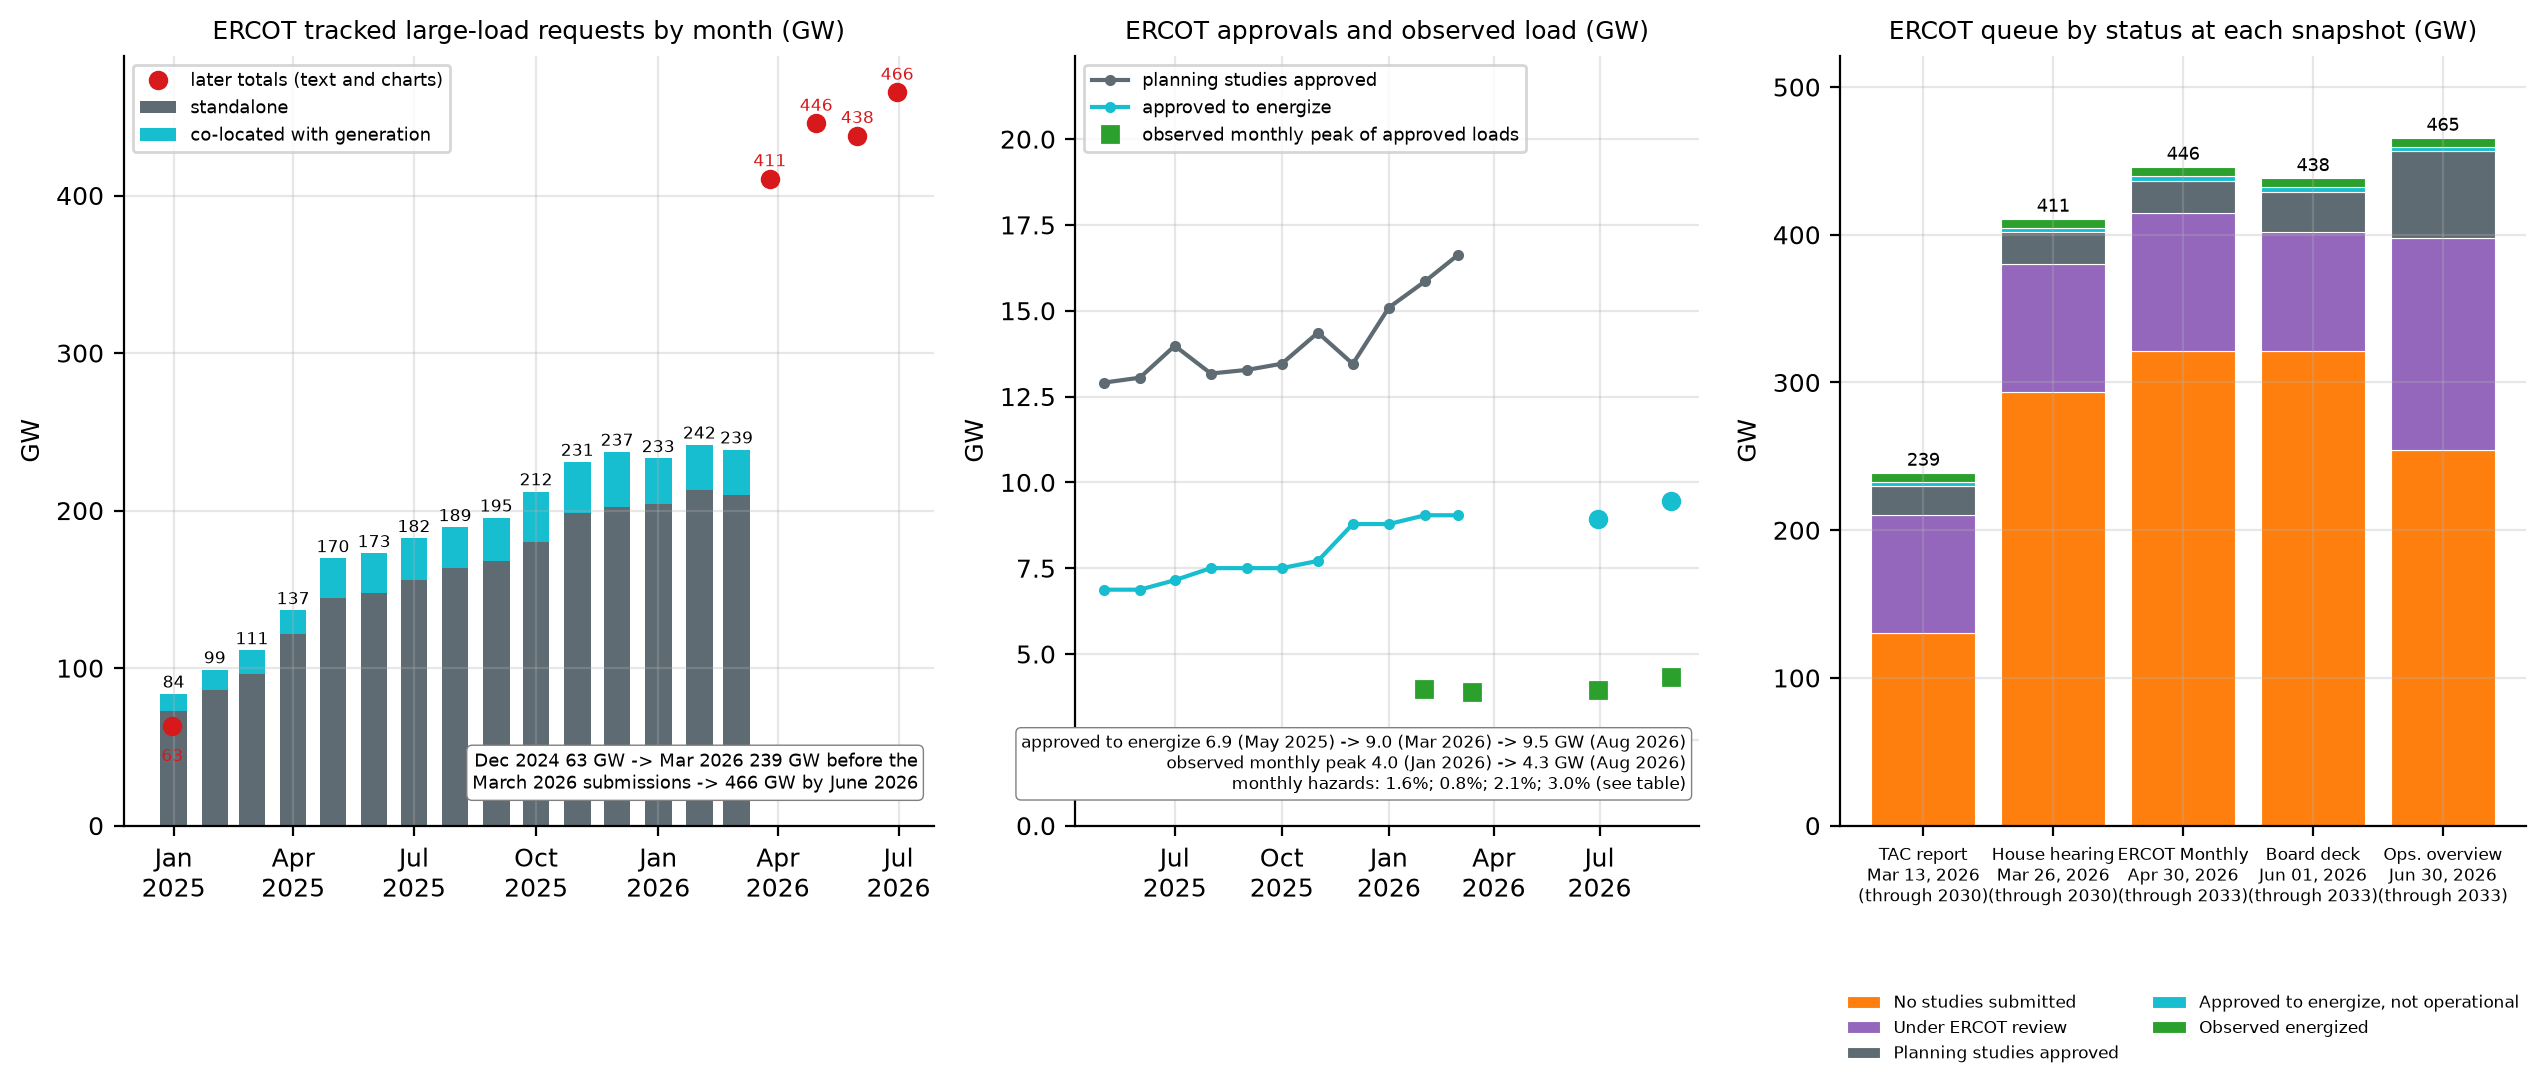

In [13]:
show("fig4_05_ercot_queue")

**Reading.** ERCOT's tracked requests went from 63 GW in December 2024 to 239 GW in March 2026 before the March 2026 submissions, then to 411 GW (87 percent data centers) and 466 GW by June 2026. Approvals moved far more slowly: planning studies approved rose from 12.9 to 16.6 GW and approvals to energize from 6.9 to 9.0 GW between May 2025 and March 2026 (9.5 GW by August 2026), and the observed monthly peak of approved loads was 4.0 to 4.3 GW. The monthly hazards are 2.1 percent from no-studies to review (an upper bound, since cancellations leave the same stock), 0.75 percent from review to studies approved, 1.6 percent from studies approved to approval to energize and 3.1 percent from approval to observed energization. At those rates a project that already has approved studies has a 37 percent chance of being energized within 60 months, one under review 6 percent and one without studies 2 percent; doubling every hazard gives 72, 25 and 12 percent.

## 3. Demand cases for 2030

Each row applies a counting rule to the same 20,677 MW: the proposal's upper bound (every MW builds, flat), the CEC's published Planning and Local Reliability values (and a literal replication of the CEC parameters: confidence 70/33/0 or 100/50/10, 67 percent utilization, a 7-year linear ramp with applications and inquiries starting in 2028), the ERCOT-calibrated chain, and the PJM rules (only signed agreements count before 2030, at 70 percent utilization with a ramp of at least 36 months; from 2030 half of non-firm requests). Energy uses a 0.88 load factor except where the CEC's own deliveries are used.

In [14]:
table("ch4_demand_cases_2030").round(3)

,case,group,p_agreement,p_application,p_inquiry,utilization,ramp_agreement,ramp_application,ramp_inquiry,load_factor,dc_peak_mw_2030,dc_energy_twh_2030,basis
0,"Upper bound: every MW builds, flat load",proposal,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,20677.0,181.131,"proposal's bound: all three tiers energized by 2030 at requested capacity, flat (load ..."
1,Upper bound at CEC utilization,proposal,1.0,1.0,1.0,0.67,1.0,1.0,1.0,0.88,13853.59,106.795,"all tiers energized by 2030, 67% utilization, load factor 0.88"
2,"CEC central (Planning forecast, published)",CEC,0.7,0.33,0.0,0.67,<NA>,<NA>,<NA>,<NA>,1583.0,12.078,CEC 2025 IEPR Planning forecast: CAISO data center peak component 2030 minus VEA (cec_...
3,"CEC central, literal replication",CEC,0.7,0.33,0.0,0.67,0.714,0.429,0.429,0.88,2365.878,18.238,confidence 70/33/0 x 67% x linear 7-year ramp (agreements from 2026: 0.71 by 2030; app...
4,"CEC high (Local Reliability, published)",CEC,1.0,0.5,0.1,0.67,<NA>,<NA>,<NA>,<NA>,4135.0,30.33,CEC 2025 IEPR Local Reliability scenario: CAISO data center peak component 2030 minus ...
5,"CEC high, literal replication",CEC,1.0,0.5,0.1,0.67,0.714,0.429,0.429,0.88,3684.206,28.401,confidence 100/50/10 x 67% x the same ramps
6,ERCOT-calibrated stock-flow,ERCOT,0.367,0.059,0.016,0.67,1.0,1.0,1.0,0.88,1622.313,12.506,probability of energization within 60 months from the ERCOT monthly hazards (inquiry =...
7,"ERCOT-calibrated, ERCOT observed utilization",ERCOT,0.367,0.059,0.016,0.638,1.0,1.0,1.0,0.88,1544.616,11.907,same probabilities; utilization = ERCOT observed energized over approved to energize (...
8,PJM-style: firm only (signed agreements),PJM,1.0,0.0,0.0,0.7,1.0,1.0,1.0,0.88,3560.2,27.445,"PJM 2026 rule: only projects with an ESO/construction commitment count before 2030, at..."
9,PJM-style: firm plus half of non-firm from 2030,PJM,1.0,0.5,0.5,0.7,1.0,1.0,1.0,0.88,9017.05,69.511,"PJM's 2030-and-later treatment of non-firm requests (50% before national scaling), app..."


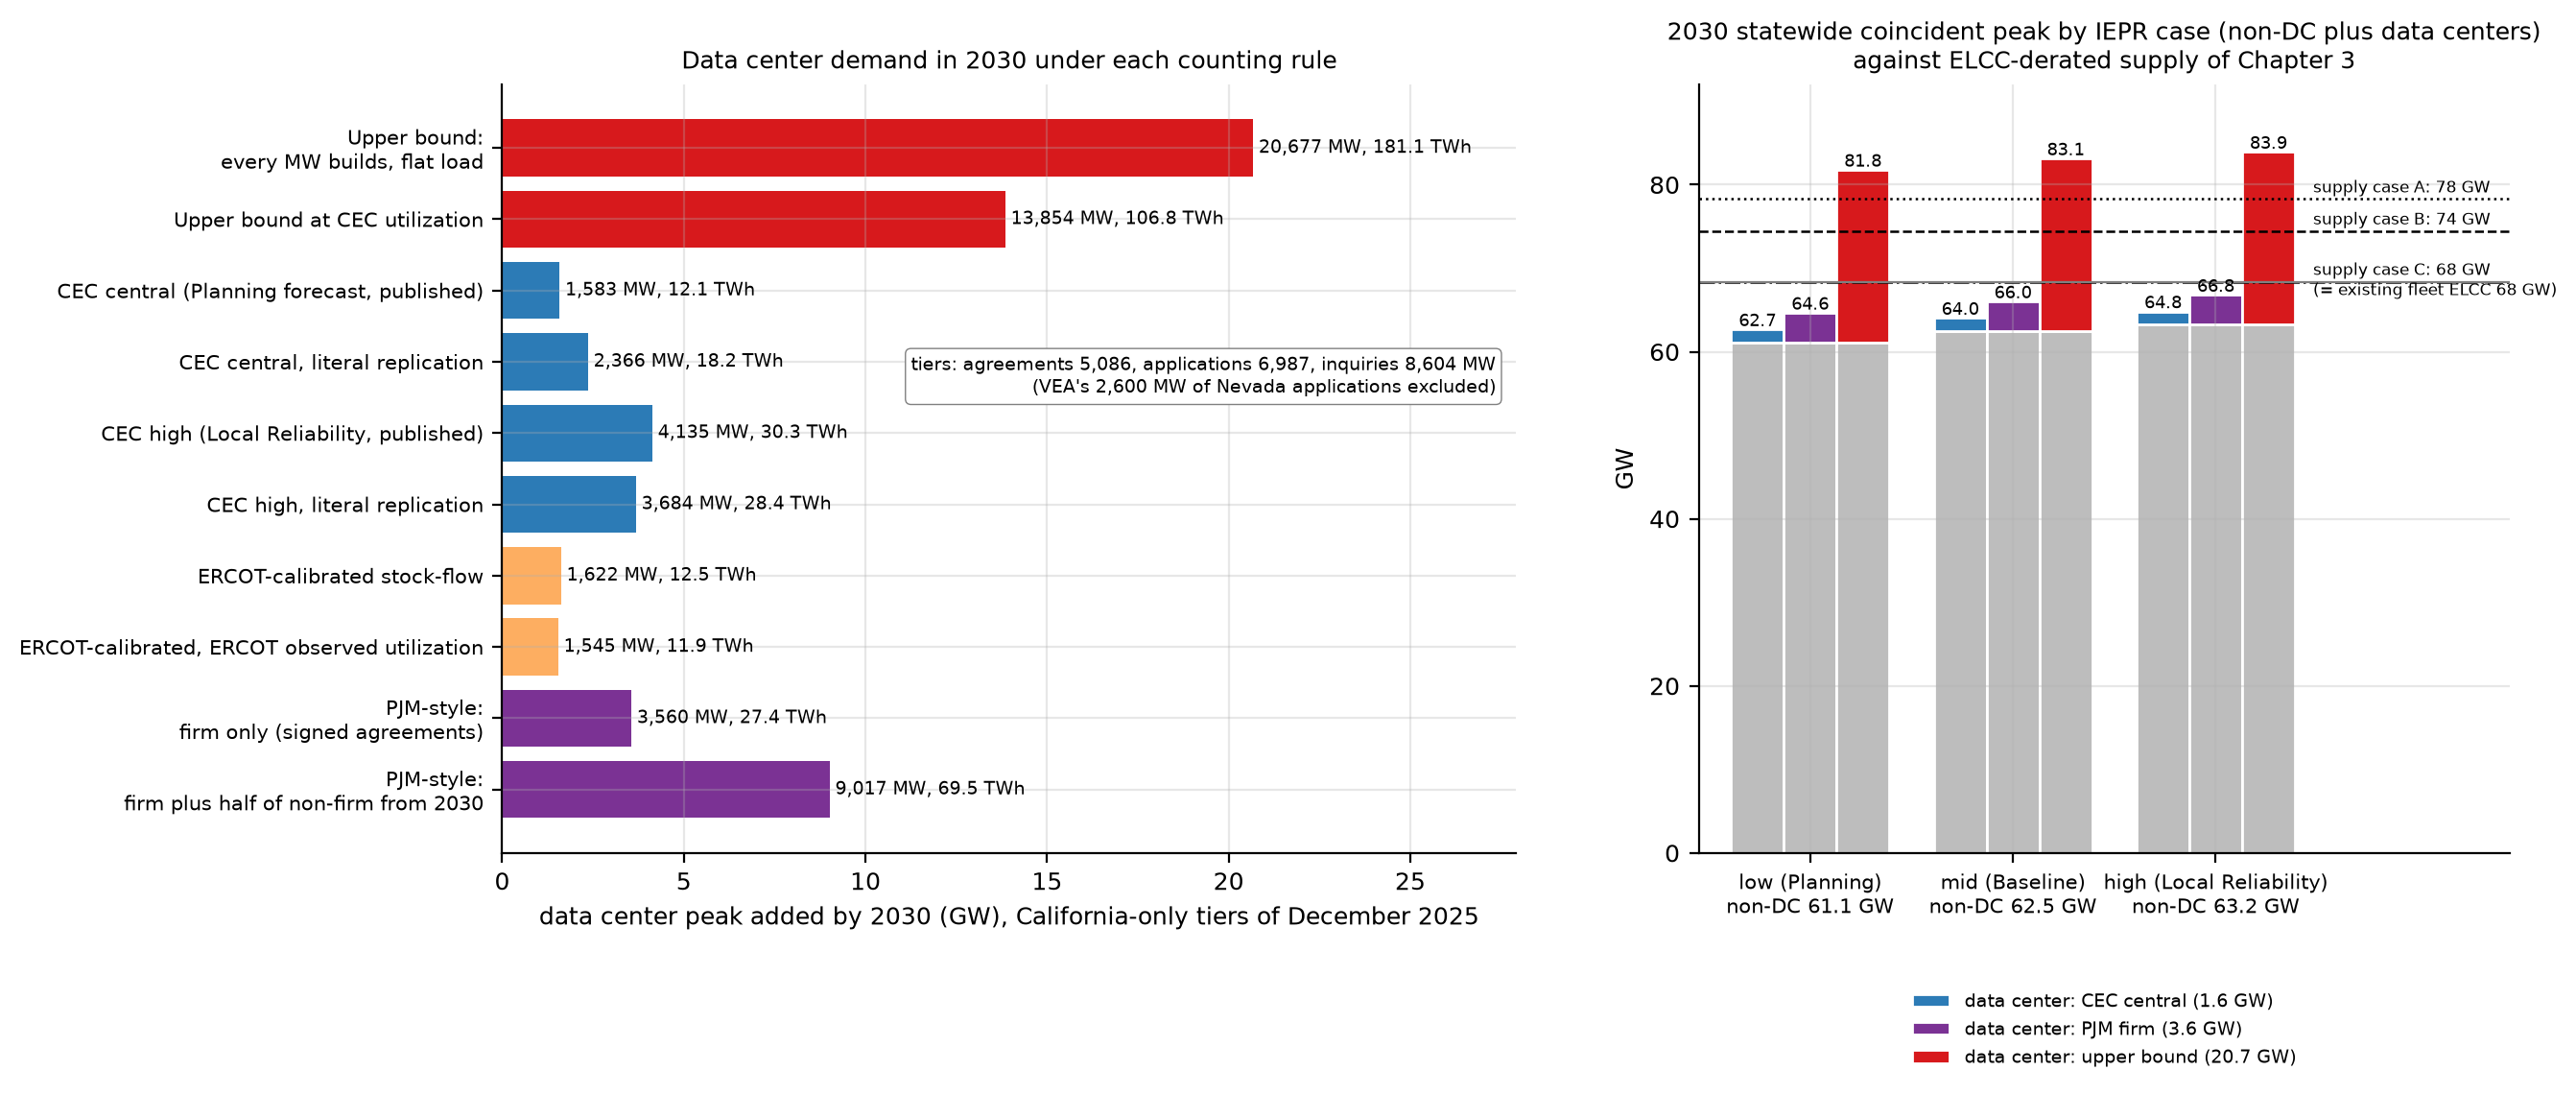

In [15]:
show("fig4_01_demand_scenarios_2030")

## 4. Monte Carlo gap model

10,000 draws over the tier realization probabilities, utilization, the share of realized capacity on line by 2030, the load factor, per-unit completion of the 229 planned generating units (chapter 3 logit probabilities), the hydro capacity factor, solar and wind output, 2030 net imports, the IEPR growth case, Diablo Canyon's status and the planning reserve margin. The **energy gap** is demand growth 2025-2030 (non-data-center growth plus the data center case) minus supply growth (weighted new capacity at recent capacity factors, minus retirements, plus the change in imports); the **net-peak gap** is demand peak growth times one plus the reserve margin minus the change in ELCC-weighted capacity. Positive values mean that demand growth outruns supply growth at recent operating patterns; the absolute balances compare 2030 levels directly (in-state ELCC only, so imports' peak contribution is excluded). The upper bound is reported in every table.

In [16]:
table("ch4_mc_inputs")

,input,distribution,low,mode,high,basis
0,p_agreement,triangular,0.5,0.7,1.0,CEC 70% (Planning) to 100% (Local Reliability); lower bound above the ERCOT chain valu...
1,p_application,triangular,0.1,0.33,0.5,CEC 33% to 50%; lower bound above the ERCOT chain value for projects under review (0.06)
2,p_inquiry,triangular,0.0,0.03,0.1,CEC 0% to 10%; mode above the ERCOT chain value for projects without studies (0.02)
3,utilization,triangular,0.46,0.67,0.7,"ERCOT monthly observed peak over approved (4,316 of 9,456 MW, Aug 2026) to PJM's 70%; ..."
4,ramp_2030,triangular,0.3,0.55,1.0,"share of realized capacity on line by end-2030: CEC literal ramps 0.43-0.71, PJM 36-mo..."
5,load_factor,triangular,0.8,0.88,0.95,chapter 1 assumption range; CEC observed 85-90% (memo p. 11)
6,gen_realization,per-unit Bernoulli,<NA>,<NA>,<NA>,"each planned unit completes with its chapter 3 logit probability p_2030 (229 units, 20..."
7,hydro_cf,triangular,0.156947,0.341573,0.483404,"hydro capacity factor 2010-2025 range 0.16-0.48, mode 2023-2025 mean"
8,vre_scale,triangular,0.9,1.0,1.1,solar and wind capacity factors within 10% of their 2023-2025 means
9,imports_twh,triangular,62.157,62.157,99.21,"CEC statewide net imports: 2019-2024 minimum 62, 2024 value 62, 2012-2024 maximum 99 TWh"


In [17]:
table("ch4_mc_summary").round(1)

,iepr_case,metric,n,mean,p05,p25,p50,p75,p95,share_positive
0,all cases,gap_energy_twh,10000,49.4,19.2,37.3,49.7,62.0,78.1,1.0
1,all cases,gap_peak_mw,10000,7181.6,4160.3,5976.1,7169.0,8498.6,10067.8,1.0
2,all cases,dc_peak_mw,10000,2358.2,1386.6,1862.5,2291.9,2783.5,3556.5,1.0
3,all cases,dc_energy_twh,10000,18.1,10.6,14.3,17.6,21.4,27.4,1.0
4,all cases,abs_energy_balance_twh,10000,33.9,3.5,21.7,34.2,46.5,62.8,1.0
5,all cases,abs_peak_balance_mw,10000,5517.1,2444.3,4265.5,5514.1,6814.2,8449.1,1.0
6,low,gap_energy_twh,3292,36.3,11.3,26.0,36.7,46.6,60.6,1.0
7,low,gap_peak_mw,3292,5793.9,3545.9,4629.6,5800.3,6904.7,8143.3,1.0
8,low,dc_peak_mw,3292,2356.4,1382.9,1859.2,2293.1,2785.6,3545.5,1.0
9,low,dc_energy_twh,3292,18.1,10.5,14.3,17.6,21.4,27.3,1.0


In [18]:
table("ch4_upper_bound_2030").round(1)

,iepr_case,diablo_continues,dc_peak_mw,dc_energy_twh,non_dc_energy_growth_twh,non_dc_peak_growth_mw,supply_energy_growth_twh,elcc_growth_mw,supply_energy_2030_twh,elcc_2030_mw,capacity_2030_mw,gap_energy_twh,gap_peak_mw,abs_energy_balance_twh,abs_peak_balance_mw,demand_energy_2030_twh,demand_peak_2030_mw
0,low,False,20677,181.1,23.6,3625.0,-15.6,472.9,262.6,68780.4,114269.9,220.3,27717.4,204.6,26068.2,467.2,81766.0
1,low,True,20677,181.1,23.6,3625.0,2.3,2679.8,280.5,70987.2,116592.9,202.4,25510.6,186.7,23861.4,467.2,81766.0
2,mid,False,20677,181.1,40.5,4987.7,-15.6,472.9,262.6,68780.4,114269.9,237.2,29298.2,222.2,27649.0,484.9,83128.8
3,mid,True,20677,181.1,40.5,4987.7,2.3,2679.8,280.5,70987.2,116592.9,219.3,27091.3,204.3,25442.1,484.9,83128.8
4,high,False,20677,181.1,45.3,5792.2,-15.6,472.9,262.6,68780.4,114269.9,242.0,30231.3,226.3,28554.8,488.9,83909.7
5,high,True,20677,181.1,45.3,5792.2,2.3,2679.8,280.5,70987.2,116592.9,224.1,28024.5,208.4,26348.0,488.9,83909.7


In [19]:
json.loads((PROCESSED / "ch4_mc_key_numbers.json").read_text())

{'base_supply': {'capacity_mw': 107511.60000000002,
  'in_state_energy_twh': 216.0536757298087,
  'imports_twh': 62.157,
  'elcc_mw': 68307.4742},
 'in_state_2025_actual_twh': 205.105814289,
 'gas_capacity_2030_mw': 36256.2,
 'gas_cf_2023_2025': 0.2439545640295861,
 'gas_cf_to_close_p50_energy_gap': 0.400305437845379,
 'gas_cf_to_close_p95_energy_gap': 0.48981969520583624,
 'draws': 10000,
 'seed': 20260922}

In [20]:
d = pd.read_parquet(PROCESSED / "ch4_mc_draws.parquet"); d.groupby(["case_name", "diablo_continues"])[["gap_energy_twh", "gap_peak_mw", "dc_peak_mw", "supply_energy_growth_twh", "elcc_growth_mw"]].median().round(1)

gap_energy_twh  gap_peak_mw  dc_peak_mw  supply_energy_growth_twh  elcc_growth_mw
case_name diablo_continues                                                                                   
high      0                           67.3       9360.8      2270.2                      -4.3            20.8
          1                           49.8       7171.2      2292.7                      13.4          2250.0
low       0                           45.0       6879.0      2307.3                      -3.7            54.9
          1                           28.0       4645.2      2280.3                      13.3          2240.2
mid       0                           63.1       8533.2      2314.8                      -4.4             3.0
          1                           45.5       6259.9      2283.4                      13.1          2210.1

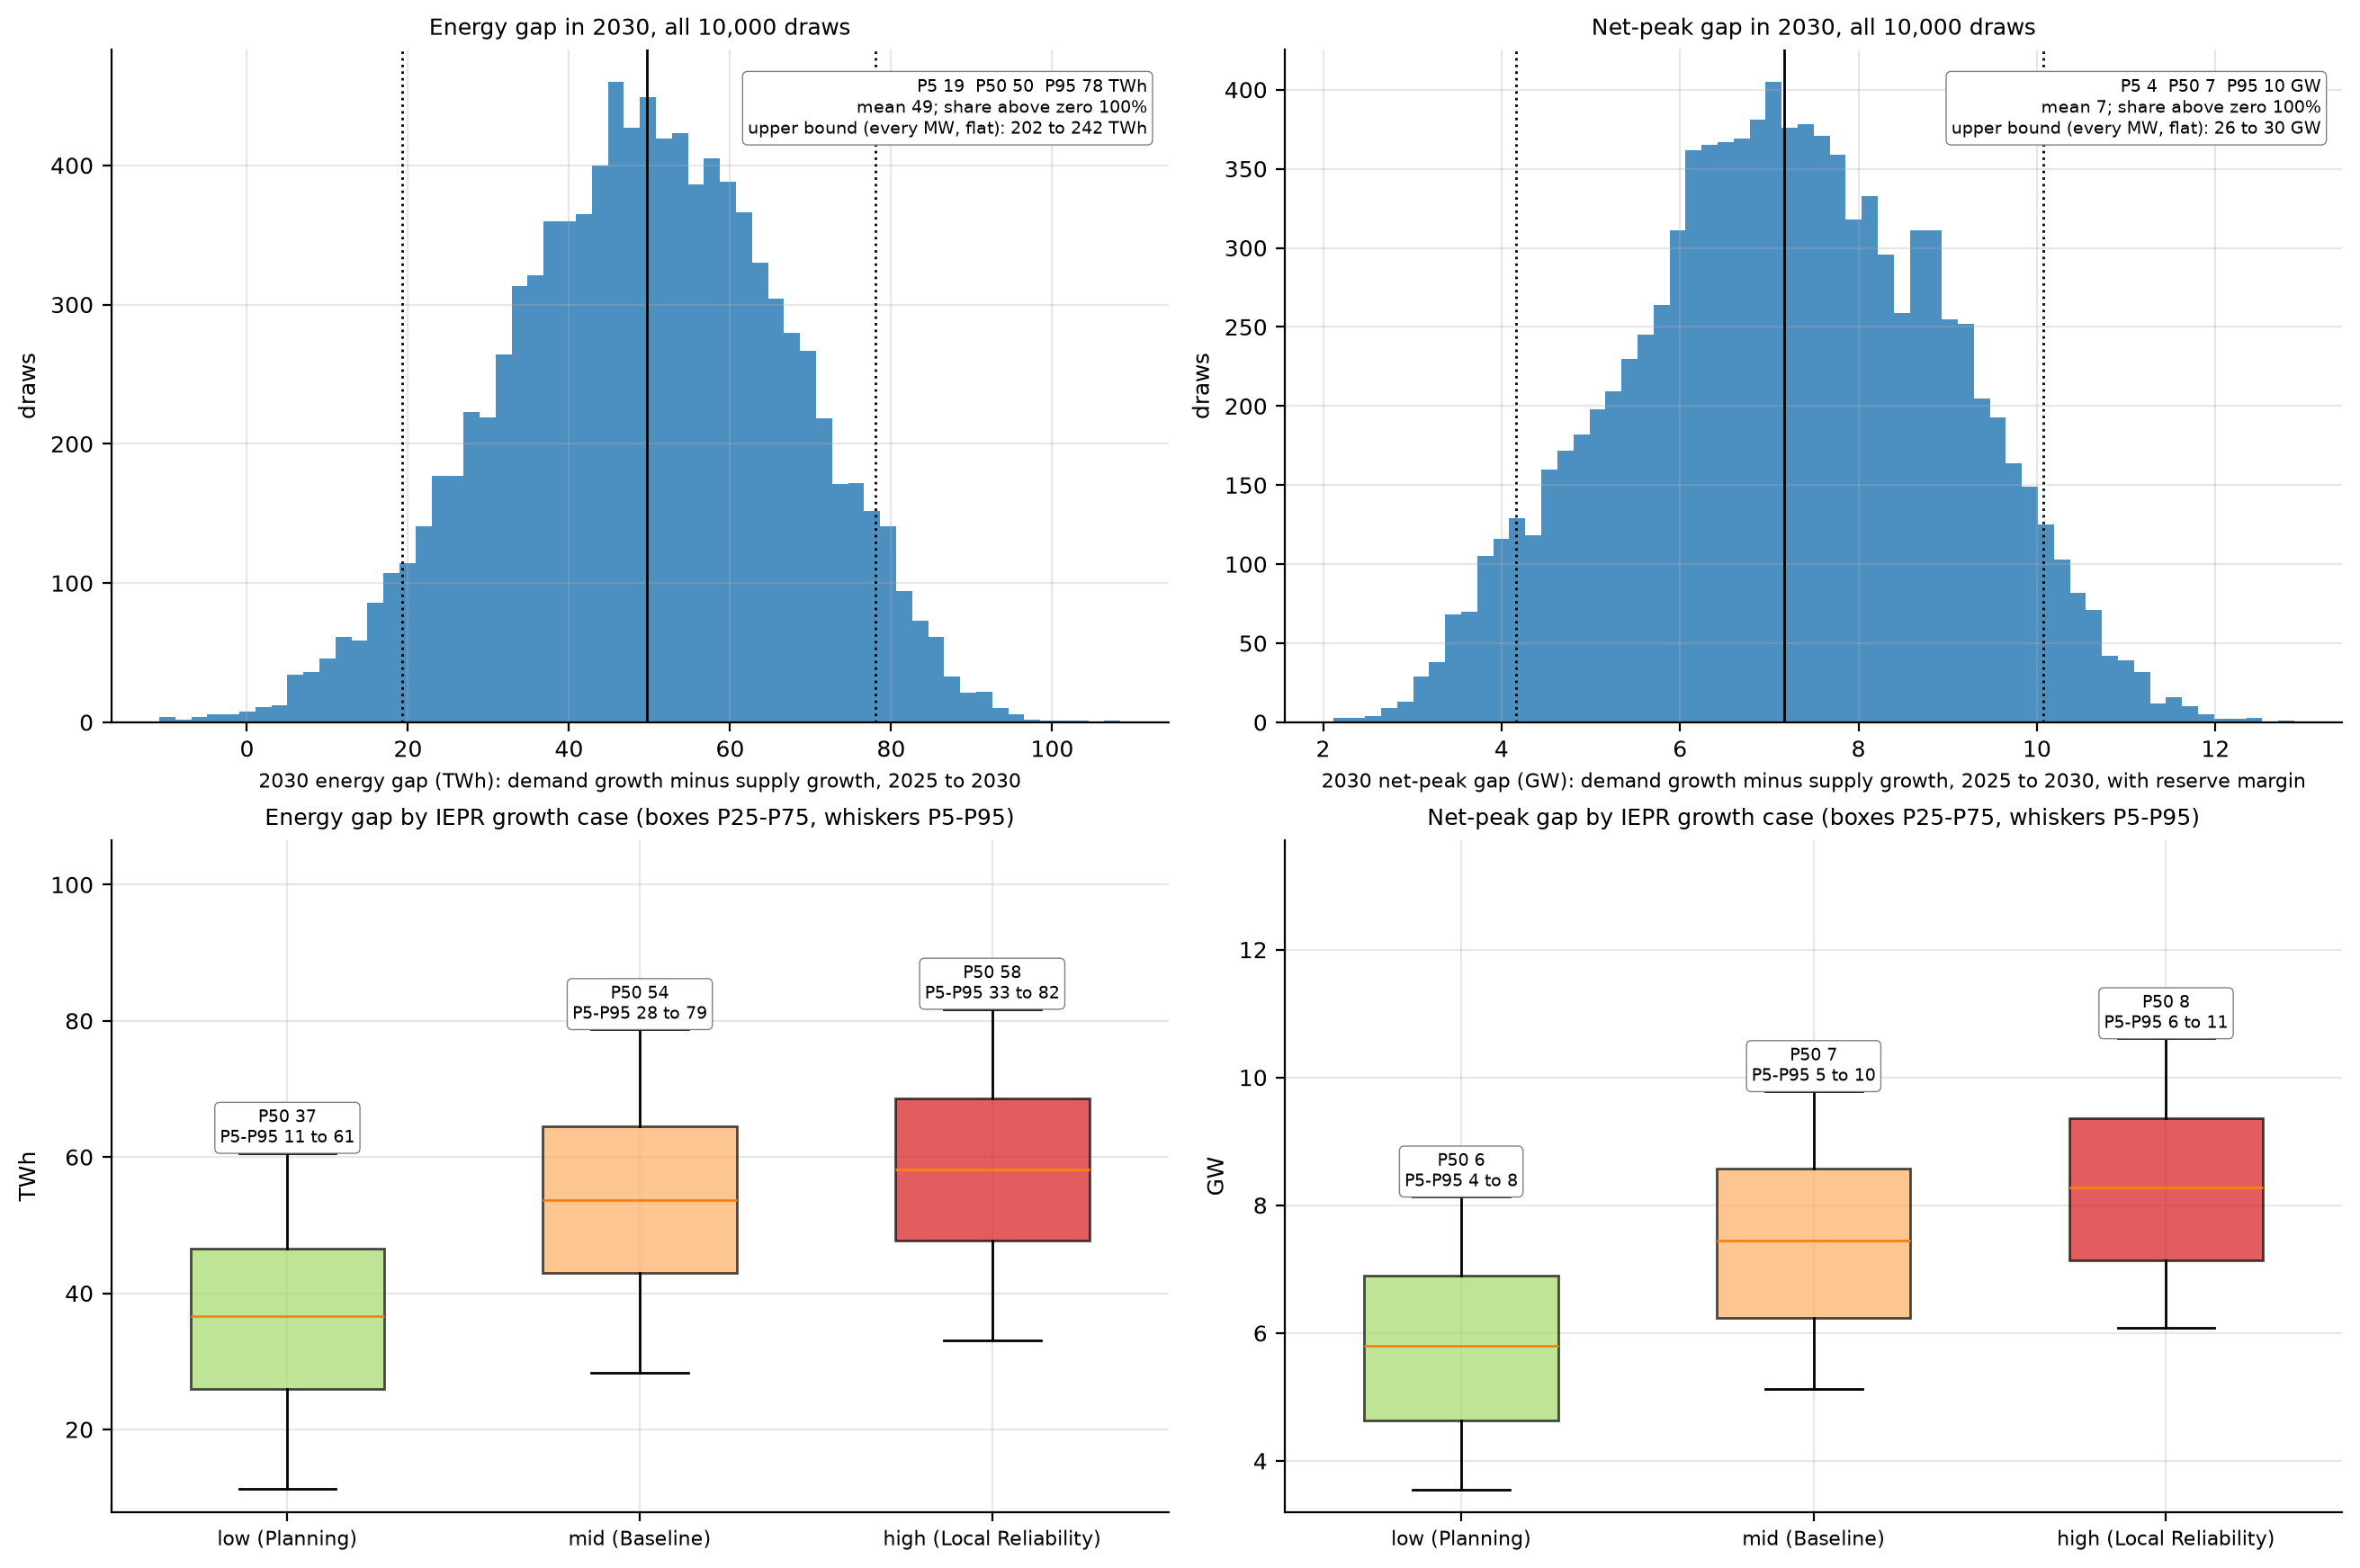

In [21]:
show("fig4_02_gap_distributions")

**Reading.** The median 2030 energy gap is 50 TWh (P5 19, P95 78) and the median net-peak gap 7.2 GW (P5 4.2, P95 10.1); both are positive in every draw because non-data-center growth alone (24 to 45 TWh, 3.6 to 5.8 GW) exceeds the supply growth the weighted pipeline delivers (mean 5 TWh and 1.1 GW of ELCC, with Diablo Canyon's 2.3 GW the single largest swing). The data center contribution is 2.3 GW and 18 TWh at the median (P5-P95 1.4 to 3.6 GW). Closing the median energy gap with the existing gas fleet would require raising its capacity factor from 0.24 to 0.40. The proposal's upper bound, every requested MW operating flat, gives an energy gap of 202 to 242 TWh and a peak gap of 25.5 to 30.2 GW, four to five times the probability-weighted P95.

## 5. Sensitivity

One-at-a-time swings hold every other input at its median and move one input between its 5th and 95th percentiles (low and high case for the IEPR case; retired and continuing for Diablo Canyon). Sobol first-order and total indices come from SALib's Sobol sequence (15,360 model evaluations); the per-unit completion is represented by its realization fraction.

In [22]:
table("ch4_tornado").round(2)

,input,low_value,high_value,gap_energy_low,gap_energy_high,gap_peak_low,gap_peak_high,base_gap_energy,base_gap_peak,swing_energy,swing_peak
0,imports_twh,63.08,91.02,65.13,37.19,6912.74,6912.74,55.35,6912.74,27.94,0.0
1,iepr_case,0.0,2.0,38.5,60.16,5332.21,7845.74,55.35,6912.74,21.66,2513.53
2,hydro_cf,0.21,0.44,65.87,46.09,6912.74,6912.74,55.35,6912.74,19.77,0.0
3,diablo_continues,0.0,1.0,64.3,46.41,8016.17,5809.32,55.35,6912.74,17.89,2206.85
4,ramp_2030,0.39,0.88,49.05,63.4,5962.12,8126.55,55.35,6912.74,14.35,2164.44
5,vre_scale,0.93,1.07,60.76,50.01,6912.74,6912.74,55.35,6912.74,10.75,0.0
6,p_application,0.17,0.44,52.4,57.92,6466.9,7299.51,55.35,6912.74,5.52,832.62
7,p_agreement,0.57,0.91,53.09,58.09,6571.03,7326.23,55.35,6912.74,5.01,755.2
8,utilization,0.51,0.68,52.21,57.16,6438.65,7185.12,55.35,6912.74,4.95,746.48
9,gen_realization,0.58,0.73,56.69,54.09,7705.34,6165.91,55.35,6912.74,2.6,1539.42


In [23]:
sb = table("ch4_sobol"); sb.pivot(index="input", columns="metric", values=["S1", "ST"]).round(3).sort_values(("ST", "gap_energy_twh"), ascending=False)

S1                         ST            
metric           gap_energy_twh gap_peak_mw gap_energy_twh gap_peak_mw
input                                                                 
iepr_case              0.276478    0.343127       0.277612     0.34948
diablo_continues       0.254749    0.390511        0.25447    0.391135
imports_twh            0.239923         0.0       0.242108         0.0
hydro_cf               0.113957         0.0       0.109651         0.0
ramp_2030              0.058669     0.12986       0.059017    0.135793
vre_scale              0.033705         0.0       0.033441         0.0
p_application          0.007909    0.017847       0.009228    0.021313
utilization            0.007851    0.018452       0.008554    0.019673
p_agreement             0.00817    0.018472       0.007726    0.017768
gen_realization         0.00228    0.072069       0.001957    0.069065
load_factor            0.001601         0.0       0.001375         0.0
p_inquiry               0.00107    0.001997       0.000912    0.002103
prm                         0.0    0.000392            0.0    0.000562

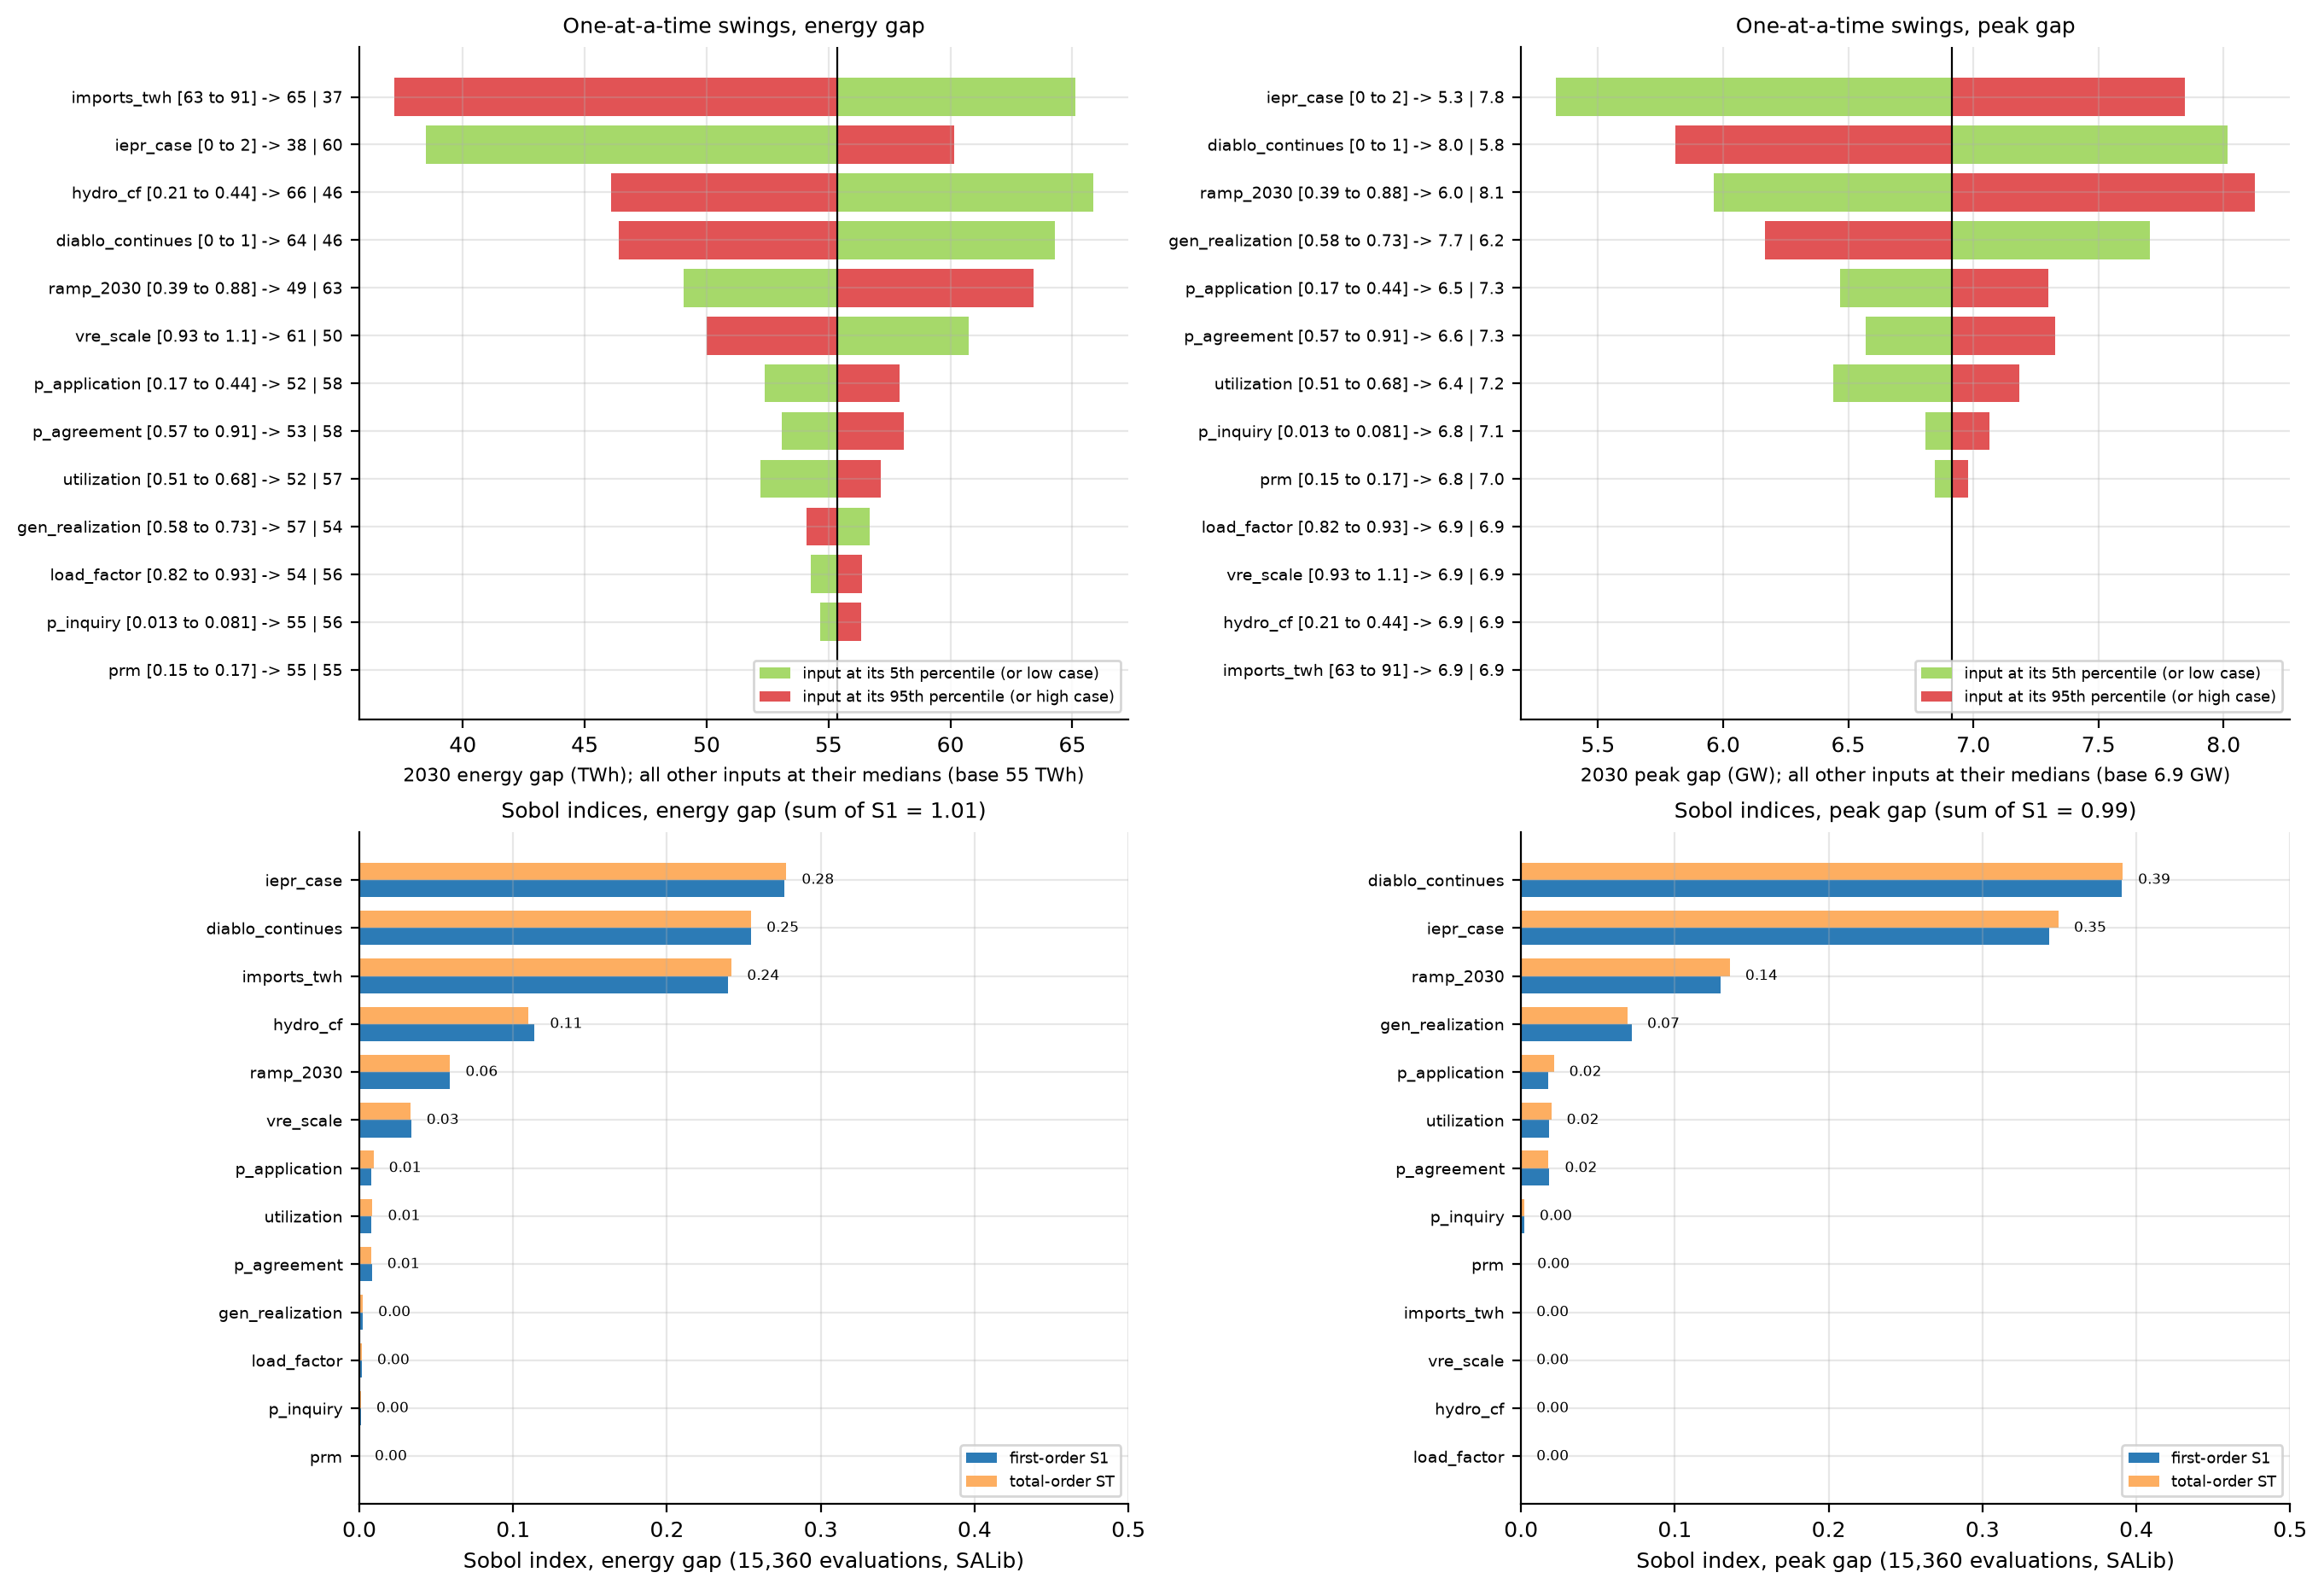

In [24]:
show("fig4_03_sensitivity")

**Reading.** The energy gap is governed by the supply side and the non-data-center forecast: imports (28 TWh swing), the IEPR case (22), hydro (20) and Diablo Canyon (18) dominate, and the three data center probabilities together explain about 3 percent of the variance. The peak gap depends on Diablo Canyon (ST 0.39), the IEPR case (0.35), the data center ramp (0.14) and generation completion (0.07). The first-order indices sum to about one in both cases, so the model is nearly additive and the tornado ranking is reliable.